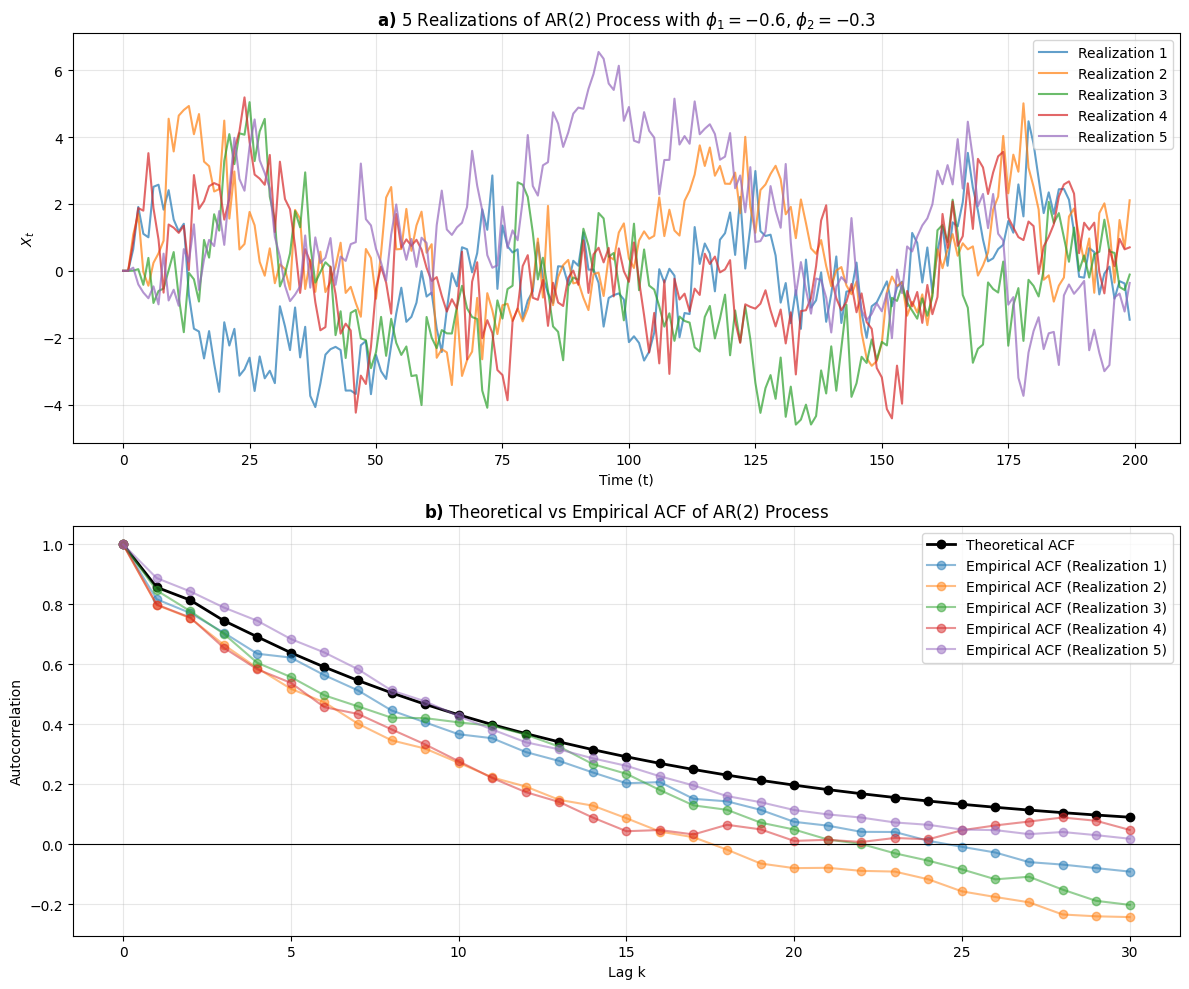

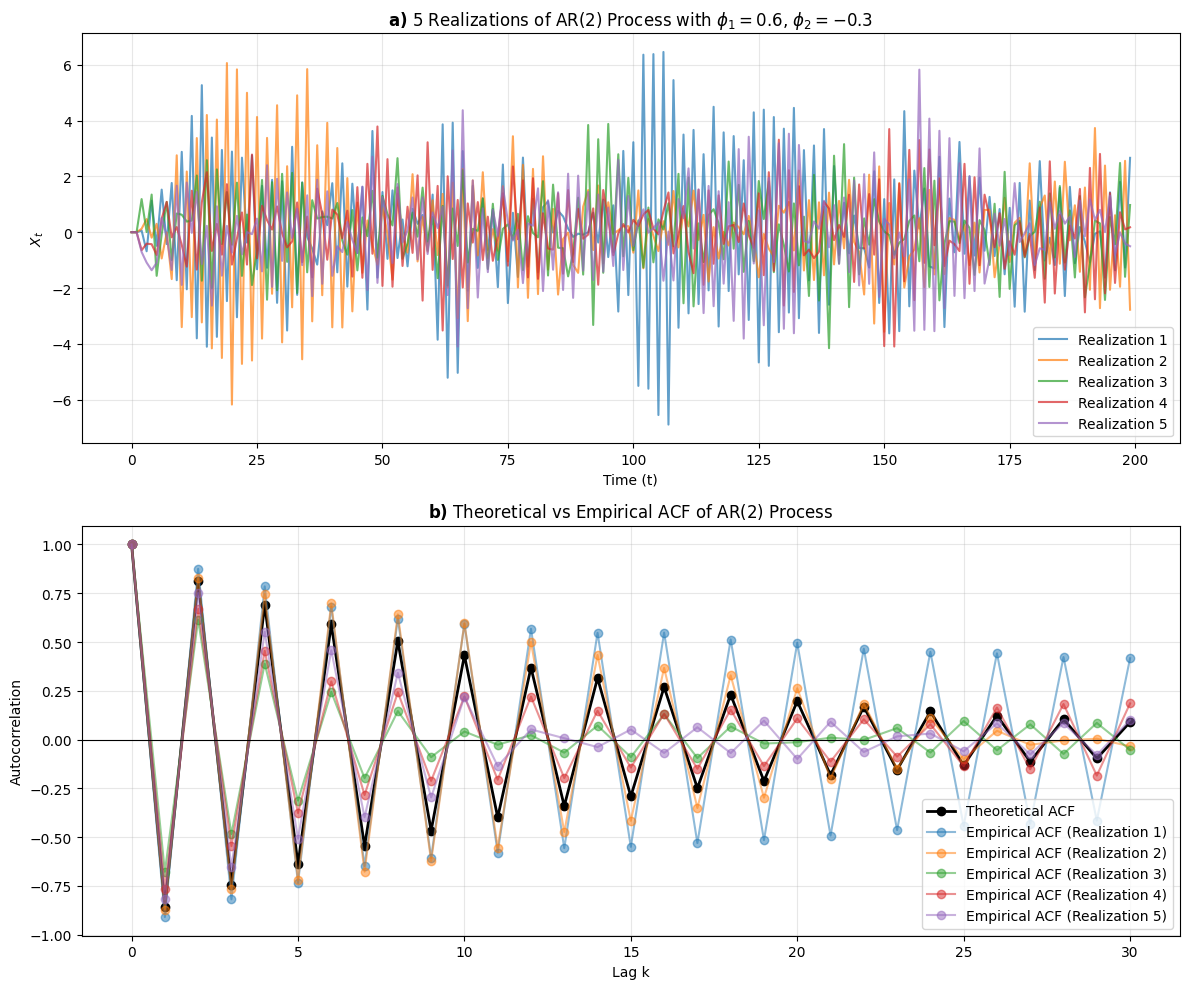

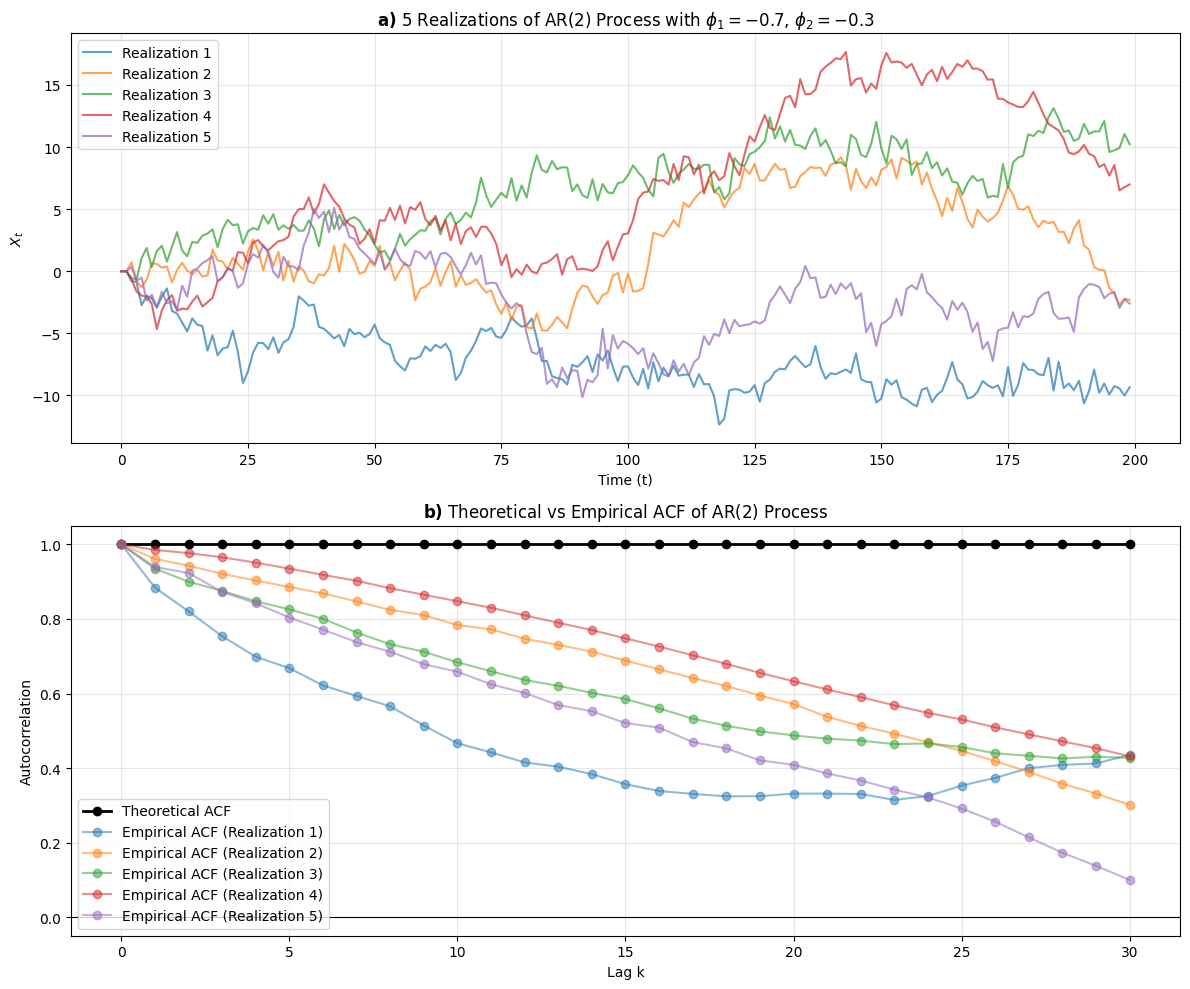

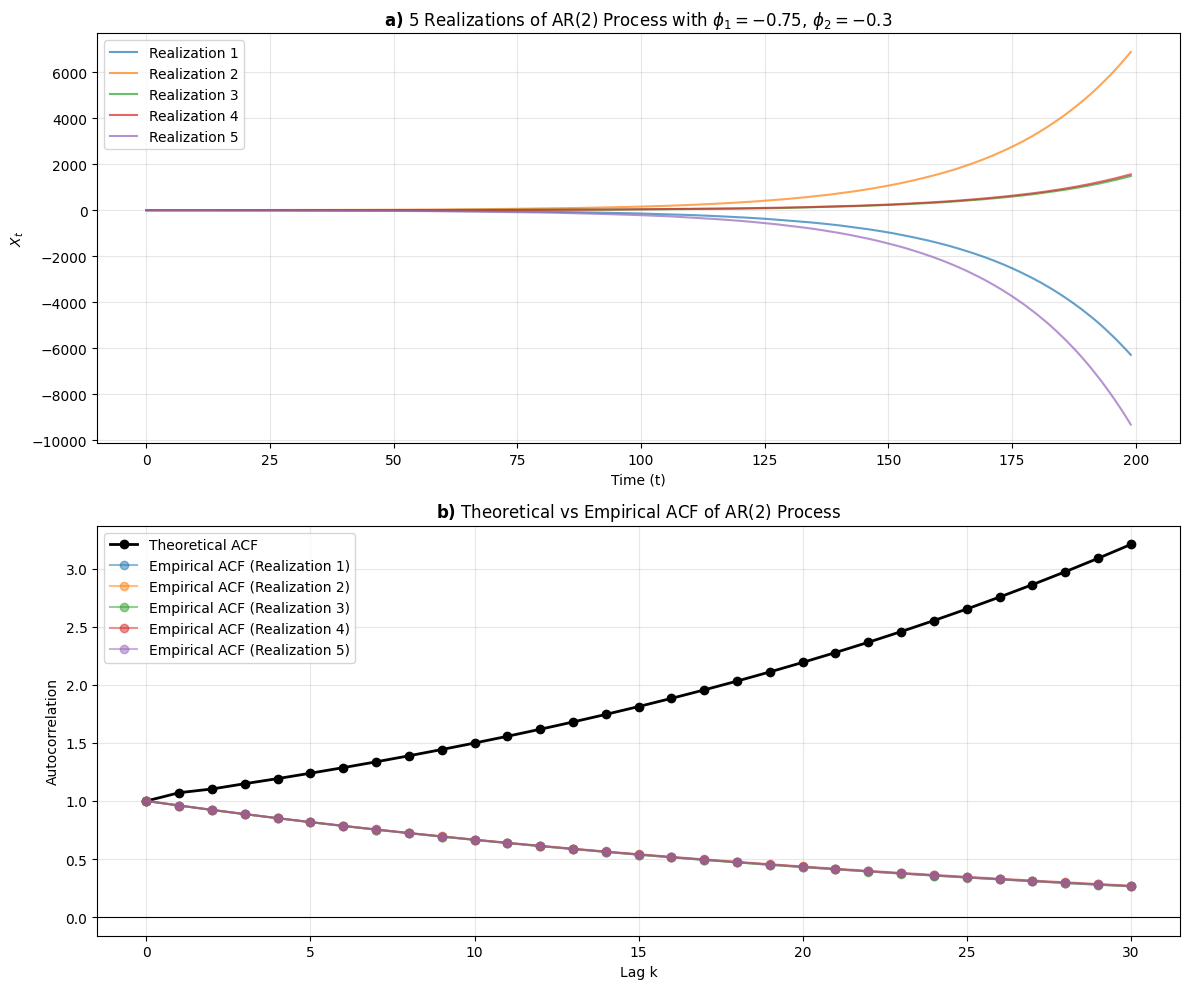

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

np.random.seed(42)

# Define parameter sets from the exercise
param_sets = [
    {"phi1": -0.6, "phi2": 0.5, "label": "1.3"},
    {"phi1": -0.6, "phi2": -0.3, "label": "1.3"},
    {"phi1": 0.6, "phi2": -0.3, "label": "1.4"},
    {"phi1": -0.7, "phi2": -0.3, "label": "1.5"},
    {"phi1": -0.75, "phi2": -0.3, "label": "1.6"}
]

# Common parameters
num_observations = 200
num_realizations = 5
sigma_epsilon = 1
nlag = 30

# Loop through each parameter set and create plots
for params in param_sets:
    phi1 = params["phi1"]
    phi2 = params["phi2"]
    label = params["label"]
    
    # Simulate realizations
    realizations = np.zeros((num_realizations, num_observations))
    
    for i in range(num_realizations):
        X = np.zeros(num_observations)
        epsilon = np.random.normal(0, sigma_epsilon, num_observations)
        for t in range(2, num_observations):
            X[t] = -phi1 * X[t-1] - phi2 * X[t-2] + epsilon[t]
        realizations[i, :] = X
    
    # Theoretical ACF up to lag 30
    rho_theoretical = np.zeros(nlag + 1)
    rho_theoretical[0] = 1
    rho_theoretical[1] = -phi1 / (1 + phi2) 
    
    for k in range(2, nlag + 1):
        rho_theoretical[k] = -phi1 * rho_theoretical[k-1] - phi2 * rho_theoretical[k-2]
    
    # Empirical ACF for each realization
    empirical_acfs = []
    for i in range(num_realizations):
        acf_values = acf(realizations[i, :], nlags=nlag, fft=False)
        empirical_acfs.append(acf_values)
    
    # Combined figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Subplot a: Realizations
    for i in range(num_realizations):
        ax1.plot(realizations[i, :], label=f'Realization {i+1}', alpha=0.7)
    
    ax1.set_xlabel("Time (t)")
    ax1.set_ylabel("$X_t$")
    ax1.set_title(f"$\\mathbf{{a)}}$ 5 Realizations of AR(2) Process with $\\phi_1 = {phi1}$, $\\phi_2 = {phi2}$")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Subplot b: Theoretical vs Empirical ACF
    ax2.plot(range(nlag + 1), rho_theoretical, 'ko-', linewidth=2, markersize=6, label='Theoretical ACF')
    
    for i in range(num_realizations):
        ax2.plot(range(nlag + 1), empirical_acfs[i], 'o-', alpha=0.5, label=f'Empirical ACF (Realization {i+1})')
    
    ax2.set_xlabel("Lag k")
    ax2.set_ylabel("Autocorrelation")
    ax2.set_title(f"$\\mathbf{{b)}}$ Theoretical vs Empirical ACF of AR(2) Process")
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"Plot{label}.png", dpi=150)
    plt.show()
    plt.close()
